# Final Model
Loads trained artifacts, verifies predictions, builds the unified `predict_asteroid` inference function, produces final visualisations, and defines the FastAPI integration interface.

In [20]:
import pandas as pd
import numpy as np
import json, joblib, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    mean_squared_error, r2_score
)

ARTIFACT_DIR = 'artifacts/'
DATA_DIR     = '../Dataset/Processed/'
sns.set_theme(style='whitegrid')

## 1. Load Artifacts

In [21]:
clf        = joblib.load(f'{ARTIFACT_DIR}classifier.joblib')
reg        = joblib.load(f'{ARTIFACT_DIR}regressor.joblib')
scaler_clf = joblib.load(f'{ARTIFACT_DIR}scaler_clf.joblib')
scaler_reg = joblib.load(f'{ARTIFACT_DIR}scaler_reg.joblib')

with open(f'{ARTIFACT_DIR}feature_names.json') as f:
    feature_names = json.load(f)
with open(f'{ARTIFACT_DIR}model_metadata.json') as f:
    metadata = json.load(f)

CLF_FEATURES = feature_names['clf_features']
REG_FEATURES = feature_names['reg_features']

print(f'Classifier:   {metadata["classifier"]["model"]}')
print(f'Regressor:    {metadata["regressor"]["model"]}')
print(f'Trained at:   {metadata["trained_at"]}')
print(f'Test F1:      {metadata["classifier"]["test_f1_weighted"]}')
print(f'Test AUC-ROC: {metadata["classifier"]["test_auc_roc"]}')
print(f'Test R2:      {metadata["regressor"]["test_r2"]}')
print(f'Test RMSE:    {metadata["regressor"]["test_rmse_km"]:,} km')

Classifier:   RandomForestClassifier
Regressor:    RandomForestRegressor
Trained at:   2026-04-19T16:12:37.087852
Test F1:      0.8763
Test AUC-ROC: 0.93
Test R2:      0.1668
Test RMSE:    22,409,891.0 km


## 2. Unified Prediction Function
Core inference function used by the FastAPI `/api/predict` endpoint.

In [22]:
def predict_asteroid(
    est_diameter_min: float,
    est_diameter_max: float,
    relative_velocity: float,
    absolute_magnitude: float,
    miss_distance: float,
) -> dict:
    """
    Predict hazard classification and miss distance for one asteroid observation.

    Returns
    -------
    dict: hazardous (bool), hazardous_probability (float), miss_distance_km (float)
    """
    diameter_avg          = (est_diameter_min + est_diameter_max) / 2
    diameter_ratio        = est_diameter_max / est_diameter_min
    log_diameter_avg      = np.log1p(diameter_avg)
    log_diameter_ratio    = np.log1p(diameter_ratio)
    log_relative_velocity = np.log1p(relative_velocity)
    log_miss_distance     = np.log1p(miss_distance)

    clf_input = pd.DataFrame([[
        log_diameter_avg, log_diameter_ratio, log_relative_velocity,
        log_miss_distance, absolute_magnitude, diameter_avg, diameter_ratio
    ]], columns=CLF_FEATURES)

    reg_input = pd.DataFrame([[
        log_diameter_avg, log_diameter_ratio, log_relative_velocity,
        absolute_magnitude, diameter_avg, diameter_ratio
    ]], columns=REG_FEATURES)

    clf_scaled = scaler_clf.transform(clf_input)
    reg_scaled = scaler_reg.transform(reg_input)

    hazardous_label       = bool(clf.predict(clf_scaled)[0])
    hazardous_probability = float(clf.predict_proba(clf_scaled)[0, 1])
    miss_distance_km      = float(np.expm1(reg.predict(reg_scaled)[0]))

    return {
        'hazardous':             hazardous_label,
        'hazardous_probability': round(hazardous_probability, 4),
        'miss_distance_km':      round(miss_distance_km, 2),
    }


# Smoke test
result = predict_asteroid(
    est_diameter_min=0.12,
    est_diameter_max=0.27,
    relative_velocity=48000.0,
    absolute_magnitude=22.1,
    miss_distance=14_500_000.0,
)
print('Sample prediction:')
print(json.dumps(result, indent=2))

Sample prediction:
{
  "hazardous": false,
  "hazardous_probability": 0.4128,
  "miss_distance_km": 33145950.46
}


## 3. Final Visualisations

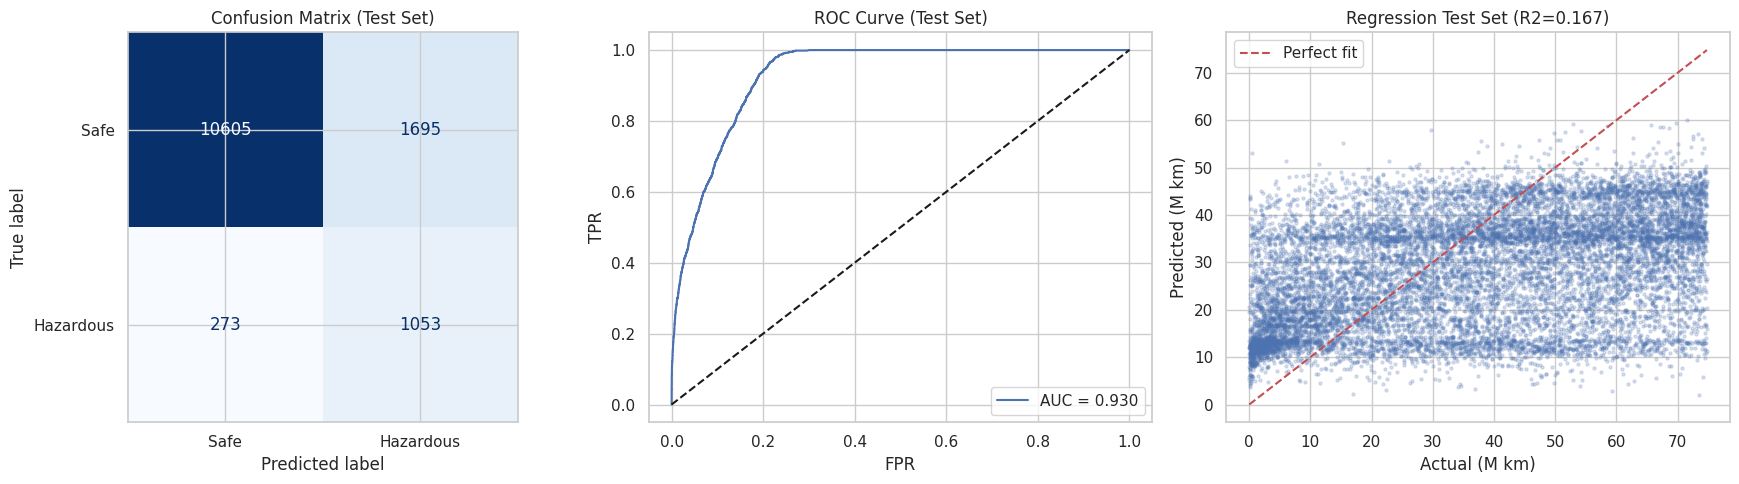

In [23]:
X_test_clf = pd.read_csv(f'{DATA_DIR}X_test_clf.csv')
y_test_clf = pd.read_csv(f'{DATA_DIR}y_test_clf.csv').squeeze()
X_test_reg = pd.read_csv(f'{DATA_DIR}X_test_reg.csv')
y_test_reg = pd.read_csv(f'{DATA_DIR}y_test_reg.csv').squeeze()

y_pred_clf  = clf.predict(X_test_clf)
y_proba_clf = clf.predict_proba(X_test_clf)[:, 1]
y_pred_reg  = reg.predict(X_test_reg)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
ConfusionMatrixDisplay(cm, display_labels=['Safe','Hazardous']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Test Set)')

# ROC curve
fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC Curve (Test Set)')
axes[1].legend()

# Predicted vs Actual (km)
y_test_km = np.expm1(y_test_reg.values)
y_pred_km = np.expm1(y_pred_reg)
axes[2].scatter(y_test_km / 1e6, y_pred_km / 1e6, alpha=0.2, s=5)
max_km = y_test_km.max() / 1e6
axes[2].plot([0, max_km], [0, max_km], 'r--', label='Perfect fit')
axes[2].set(xlabel='Actual (M km)', ylabel='Predicted (M km)',
            title=f'Regression Test Set (R2={r2_score(y_test_reg, y_pred_reg):.3f})')
axes[2].legend()

plt.tight_layout()
plt.show()

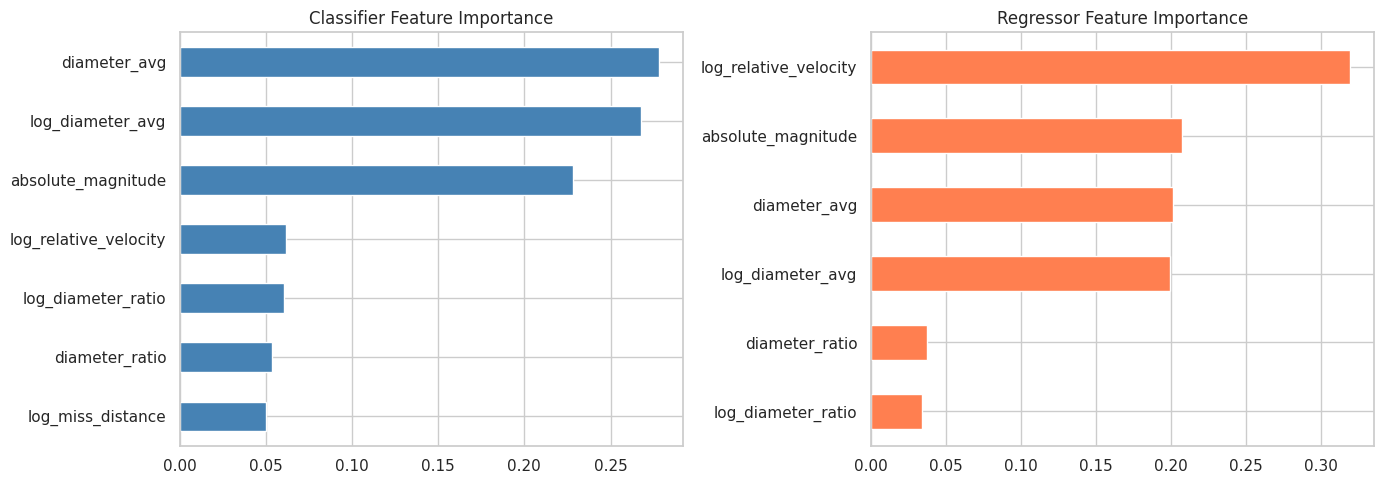

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
pd.Series(clf.feature_importances_, index=CLF_FEATURES).sort_values().plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Classifier Feature Importance')
pd.Series(reg.feature_importances_, index=REG_FEATURES).sort_values().plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Regressor Feature Importance')
plt.tight_layout()
plt.show()

## 4. FastAPI Integration — Reference Implementation

The block below shows the updated `server/app.py`. It is already written to that file — this cell is documentation only.

```python
from contextlib import asynccontextmanager
from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np, pandas as pd, joblib, json

class AsteroidInput(BaseModel):
    est_diameter_min:   float
    est_diameter_max:   float
    relative_velocity:  float
    absolute_magnitude: float
    miss_distance:      float

class PredictionOutput(BaseModel):
    hazardous:             bool
    hazardous_probability: float
    miss_distance_km:      float

ARTIFACT_DIR = '../models/artifacts/'
models = {}

@asynccontextmanager
async def lifespan(app: FastAPI):
    models['clf']          = joblib.load(f'{ARTIFACT_DIR}classifier.joblib')
    models['reg']          = joblib.load(f'{ARTIFACT_DIR}regressor.joblib')
    models['scaler_clf']   = joblib.load(f'{ARTIFACT_DIR}scaler_clf.joblib')
    models['scaler_reg']   = joblib.load(f'{ARTIFACT_DIR}scaler_reg.joblib')
    with open(f'{ARTIFACT_DIR}feature_names.json') as f:
        models['feature_names'] = json.load(f)
    yield
    models.clear()

app = FastAPI(lifespan=lifespan)

@app.post('/api/predict', response_model=PredictionOutput)
def predict(body: AsteroidInput):
    diameter_avg          = (body.est_diameter_min + body.est_diameter_max) / 2
    diameter_ratio        = body.est_diameter_max / body.est_diameter_min
    log_diameter_avg      = np.log1p(diameter_avg)
    log_diameter_ratio    = np.log1p(diameter_ratio)
    log_relative_velocity = np.log1p(body.relative_velocity)
    log_miss_distance     = np.log1p(body.miss_distance)

    CLF_FEATURES = models['feature_names']['clf_features']
    REG_FEATURES = models['feature_names']['reg_features']

    clf_input = pd.DataFrame([[
        log_diameter_avg, log_diameter_ratio, log_relative_velocity,
        log_miss_distance, body.absolute_magnitude, diameter_avg, diameter_ratio
    ]], columns=CLF_FEATURES)
    reg_input = pd.DataFrame([[
        log_diameter_avg, log_diameter_ratio, log_relative_velocity,
        body.absolute_magnitude, diameter_avg, diameter_ratio
    ]], columns=REG_FEATURES)

    clf_s = models['scaler_clf'].transform(clf_input)
    reg_s = models['scaler_reg'].transform(reg_input)

    return PredictionOutput(
        hazardous=bool(models['clf'].predict(clf_s)[0]),
        hazardous_probability=round(float(models['clf'].predict_proba(clf_s)[0, 1]), 4),
        miss_distance_km=round(float(np.expm1(models['reg'].predict(reg_s)[0])), 2),
    )
```

## 5. Final Metrics Summary

In [25]:
summary = pd.DataFrame([
    {'Task': 'Classification', 'Metric': 'F1 (weighted)',  'Value': metadata['classifier']['test_f1_weighted']},
    {'Task': 'Classification', 'Metric': 'AUC-ROC',        'Value': metadata['classifier']['test_auc_roc']},
    {'Task': 'Regression',     'Metric': 'R2',             'Value': metadata['regressor']['test_r2']},
    {'Task': 'Regression',     'Metric': 'RMSE (log)',     'Value': metadata['regressor']['test_rmse_log']},
    {'Task': 'Regression',     'Metric': 'RMSE (km)',      'Value': f"{int(metadata['regressor']['test_rmse_km']):,}"},
])
print(summary.to_string(index=False))

          Task        Metric      Value
Classification F1 (weighted)     0.8763
Classification       AUC-ROC       0.93
    Regression            R2     0.1668
    Regression    RMSE (log)     1.0427
    Regression     RMSE (km) 22,409,891
